In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
(X_train, y_train), (X_test, y_test)= cifar10.load_data()
print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


<function matplotlib.pyplot.show(close=None, block=None)>

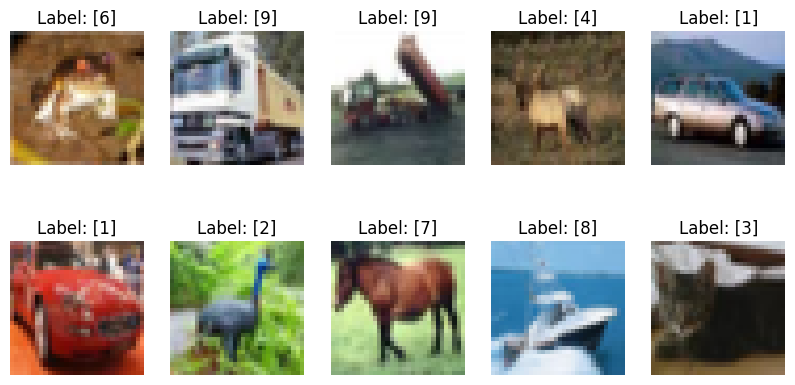

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i],cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:

X_train = X_train.reshape(-1,32,32,3)
X_test = X_test.reshape(-1,32,32,3)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
print("Shape of y_train after to_categorical:", y_train.shape)
print("Shape of y_test after to_categorical:", y_test.shape)

Shape of y_train after to_categorical: (50000, 10)
Shape of y_test after to_categorical: (10000, 10)


In [ ]:
model = Sequential()

#First Convolution layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
#First Pooling Layer
model.add(MaxPooling2D((2,2)))

#Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
#Second Pooling Layer
model.add(MaxPooling2D((2,2)))

#third convolution layer
model.add(Conv2D(128, (3,3), activation='relu'))
#third pooling
model.add(MaxPooling2D((2,2)))

#Flatten Layer
model.add(Flatten())

#Fully Connected Layer
model.add(Dense(128, activation='relu'))

#Dropout Layer
model.add(Dropout(0.5))

#Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics =['accuracy'])

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs =10, batch_size=32, validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 63s 49ms/step - accuracy: 0.3806 - loss: 1.6731 - val_accuracy: 0.5065 - val_loss: 1.4060
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 50ms/step - accuracy: 0.5270 - loss: 1.3133 - val_accuracy: 0.5895 - val_loss: 1.1623
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 50ms/step - accuracy: 0.5896 - loss: 1.1587 - val_accuracy: 0.6263 - val_loss: 1.0759
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 63s 51ms/step - accuracy: 0.6315 - loss: 1.0512 - val_accuracy: 0.6547 - val_loss: 0.9875
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 61s 49ms/step - accuracy: 0.6597 - loss: 0.9740 - val_accuracy: 0.6726 - val_loss: 0.9260
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.6866 - loss: 0.9049 - val_accuracy: 0.6715 - val_loss: 0.9438
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.7046 - loss: 0.8454 - val_accuracy: 0.6976 - val_loss: 0.8793
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 49ms/step - accuracy: 0.7191 -

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7052 - loss: 0.8812
Test Loss: 0.881210446357727
Test Accuracy: 0.7052000164985657


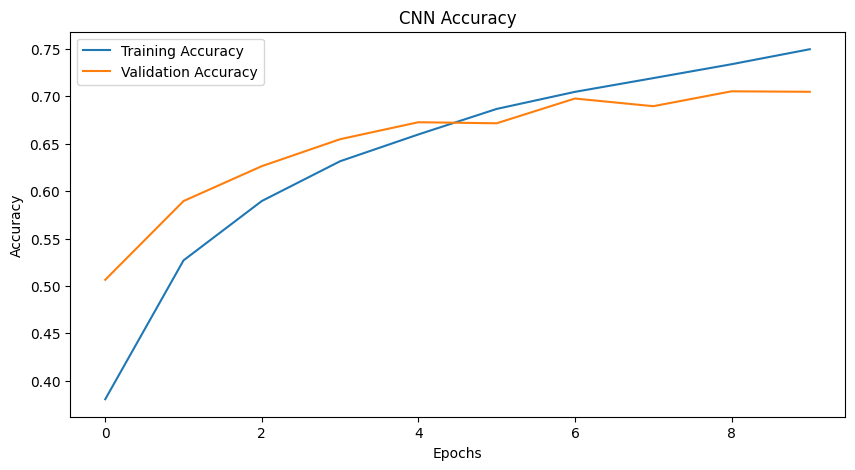

In [ ]:
#Accuracy Curve
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()
plt.show()

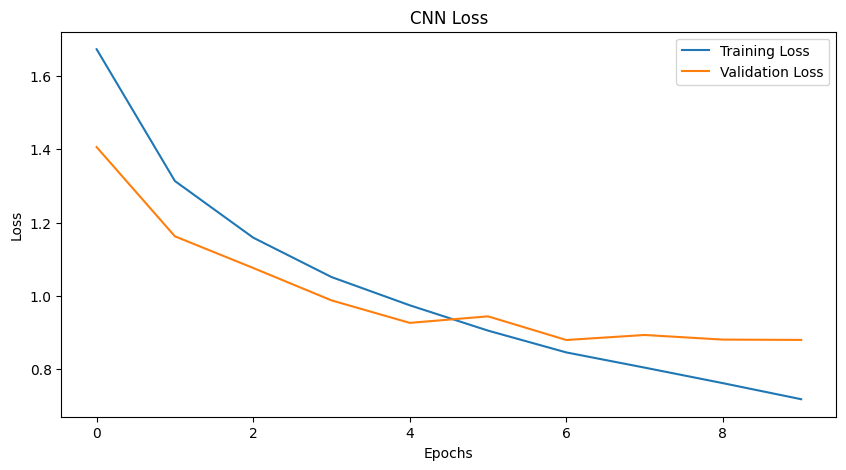

In [ ]:
#Loss Curve
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Loss')
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


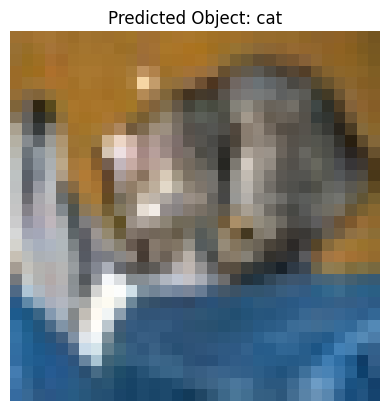

In [ ]:
cifar10_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

sample_index = 0 # You can change this index to view different images
sample = X_test[sample_index]

# Reshape the sample for prediction (add batch dimension) and ensure correct shape (32,32,3)
prediction = model.predict(sample.reshape(1, 32, 32, 3))
predicted_class_index = np.argmax(prediction)
predicted_class_name = cifar10_class_names[predicted_class_index]

plt.imshow(sample) # No cmap='gray' needed for RGB images
plt.title(f"Predicted Object: {predicted_class_name}")
plt.axis('off')
plt.show()

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import cv2

print("Please upload an image file (e.g., a .jpg or .png of an airplane, car, etc.):")
uploaded = files.upload()

if not uploaded:
    print("No file uploaded. Please upload an image to proceed.")
else:
    img_path = list(uploaded.keys())[0]

    # Load the image in color (remove IMREAD_GRAYSCALE)
    img = cv2.imread(img_path)

    # Resize the image to 32x32, which is the input size for CIFAR-10 images
    img = cv2.resize(img, (32, 32))

    # Convert BGR to RGB (OpenCV loads images in BGR format)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Normalize the image to the same scale as training data (0-1)
    img = img / 255.0

    # Display Image
    plt.figure(figsize=(4, 4))
    plt.imshow(img) # No cmap='gray' for color images
    plt.title("Uploaded Input Image")
    plt.axis('off')
    plt.show()

    # Reshape for CNN: (1, 32, 32, 3) for a single color image
    img_for_prediction = np.expand_dims(img, axis=0)

    # Predict the image
    prediction = model.predict(img_for_prediction)
    predicted_class_index = np.argmax(prediction)
    predicted_class_name = class_names[predicted_class_index]

    print(f"Predicted Type: {predicted_class_name}")

    # Print the confidence score
    print("Confidence Score:", np.max(prediction) * 100, "%")